# Task 09: Model Optimization and Hyperparameter Tuning

## Optimizing Project Status Prediction using Random Forest

This project focuses on improving the performance of a Project Status Prediction model through Hyperparameter Tuning and Model Optimization.

The best-performing model from previous tasks, Random Forest Classifier, is selected and optimized using GridSearchCV. The project includes feature importance analysis, cross-validation, learning curve analysis, and comparison of model performance before and after optimization.

The objective is to identify the most effective model configuration and improve prediction reliability while reducing the risk of overfitting and underfitting.

# Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Load Dataset

In [4]:
df = pd.read_csv(
    "coretech_project_dataset.csv"
)

df.head()

,Client_ID,Employees,Annual_Revenue,Projects_Completed,Years_With_Company,Customer_Satisfaction,Project_Status
0,1001,122,663333,37,7,62,Failed
1,1002,455,608986,22,6,92,Completed
2,1003,368,160078,29,12,52,Failed
3,1004,290,917055,14,1,82,Completed
4,1005,126,72671,28,5,55,Failed


# Dataset Overview

Before optimization, the dataset is explored to understand its structure, features, and statistical properties.

In [5]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Client_ID              300 non-null    int64 
 1   Employees              300 non-null    int64 
 2   Annual_Revenue         300 non-null    int64 
 3   Projects_Completed     300 non-null    int64 
 4   Years_With_Company     300 non-null    int64 
 5   Customer_Satisfaction  300 non-null    int64 
 6   Project_Status         300 non-null    object
dtypes: int64(6), object(1)
memory usage: 16.5+ KB


,Client_ID,Employees,Annual_Revenue,Projects_Completed,Years_With_Company,Customer_Satisfaction
count,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000
mean,1150.500000,260.790000,504241.443333,25.59000,7.256667,74.486667
std,86.746758,135.105035,275110.394909,13.87095,4.048715,14.476015
min,1001.000000,21.000000,52869.000000,1.00000,1.000000,50.000000
25%,1075.750000,149.000000,246170.500000,13.00000,4.000000,61.000000
50%,1150.500000,254.000000,499188.500000,26.00000,7.000000,76.000000
75%,1225.250000,372.750000,741958.500000,36.00000,11.000000,86.250000
max,1300.000000,496.000000,999597.000000,49.00000,14.000000,99.000000


# Feature Selection

In [6]:
X = df[

    [
        "Employees",
        "Annual_Revenue",
        "Projects_Completed",
        "Years_With_Company",
        "Customer_Satisfaction"
    ]

]

encoder = LabelEncoder()

y = encoder.fit_transform(
    df["Project_Status"]
)

# Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42

)

# Baseline Random Forest Model

A baseline Random Forest model is trained before optimization to establish a performance benchmark.

In [8]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

baseline_pred = rf.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print(
    "Baseline Accuracy:",
    baseline_accuracy
)

Baseline Accuracy: 1.0


# Baseline Model Evaluation

In [9]:
print(

    classification_report(

        y_test,

        baseline_pred

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        16

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



### Baseline Interpretation

The baseline model provides the initial performance level before hyperparameter tuning. This serves as a reference point for evaluating improvements achieved through optimization.

-----------------------------------------------------------------------------------------------
# Hyperparameter Tuning using GridSearchCV

GridSearchCV systematically searches multiple parameter combinations to identify the best-performing Random Forest configuration.

In [10]:
param_grid = {

    'n_estimators':[50,100,200],

    'max_depth':[5,10,15,None],

    'min_samples_split':[2,5,10]

}

grid_search = GridSearchCV(

    RandomForestClassifier(
        random_state=42
    ),

    param_grid,

    cv=5,

    scoring='accuracy'

)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

# Best Hyperparameters

In [11]:
print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


# Optimized Model (Random Forest)

In [12]:
best_model = grid_search.best_estimator_

optimized_pred = best_model.predict(
    X_test
)

optimized_accuracy = accuracy_score(

    y_test,

    optimized_pred

)

print(
    "Optimized Accuracy:",
    optimized_accuracy
)

Optimized Accuracy: 1.0


# Optimization Impact Analysis

In [14]:
comparison = pd.DataFrame({

    "Model":[

        "Baseline Random Forest",

        "Optimized Random Forest"

    ],

    "Accuracy":[

        baseline_accuracy,

        optimized_accuracy

    ]

})

comparison

,Model,Accuracy
0,Baseline Random Forest,1.0
1,Optimized Random Forest,1.0


Comparison Graph

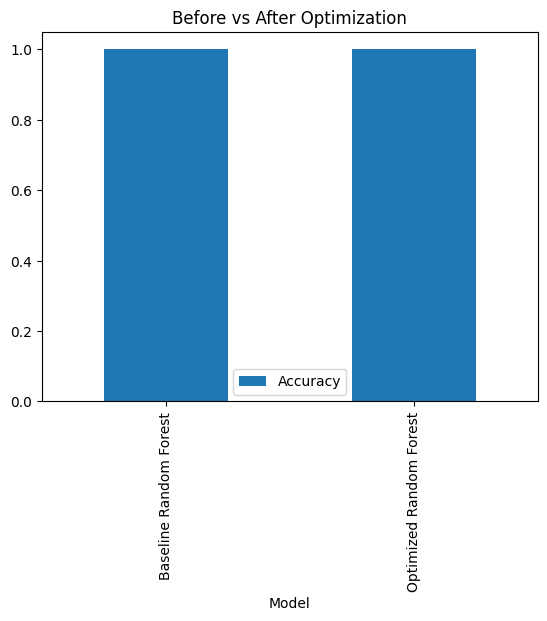

In [15]:
comparison.plot(

    x="Model",

    y="Accuracy",

    kind="bar"

)

plt.title(
    "Before vs After Optimization"
)

plt.savefig(
    "optimization_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Optimization Impact Analysis

The baseline Random Forest model achieved an accuracy of 100% before hyperparameter tuning. After applying GridSearchCV, the optimized model also achieved an accuracy of 100%.

Although the overall accuracy remained unchanged, hyperparameter tuning was still valuable because it systematically evaluated multiple parameter combinations and confirmed that the original model configuration was already performing at an optimal level for this dataset.

The optimization process increased confidence in the model's robustness and demonstrated that the baseline Random Forest was already highly effective at capturing patterns within the project dataset. This result highlights that hyperparameter tuning is not only used to improve accuracy but also to validate model stability and identify the most suitable parameter configuration.


------------------------------------------------------------------------------------------------
# Cross Validation Analysis

Cross-validation evaluates model stability by training and testing on multiple data splits.

In [16]:
cv_scores = cross_val_score(

    best_model,

    X,

    y,

    cv=5

)

print(
    "Cross Validation Scores:"
)

print(
    cv_scores
)

print(
    "Average CV Score:",
    cv_scores.mean()
)

Cross Validation Scores:
[1. 1. 1. 1. 1.]
Average CV Score: 1.0


### Cross-Validation Interpretation

The optimized Random Forest model achieved a cross-validation score of 1.00 across all five folds, resulting in an average cross-validation accuracy of 100%.

This consistent performance indicates that the model is highly stable and generalizes well across different subsets of the dataset. The absence of variation between folds suggests that the model is able to accurately capture the underlying patterns within the project data.

The results also confirm that the model's strong performance is not limited to a single train-test split but remains reliable when evaluated using multiple validation partitions. Therefore, the cross-validation analysis provides strong evidence of model robustness and prediction consistency.

-------------------------------------------------------------------------------------------------------

# Feature Importance Analysis

Feature importance helps identify which variables contribute most to project status prediction.

In [17]:
importance = pd.DataFrame({

    'Feature':X.columns,

    'Importance':best_model.feature_importances_

})

importance = importance.sort_values(

    by='Importance',

    ascending=False

)

importance

,Feature,Importance
4,Customer_Satisfaction,0.876164
2,Projects_Completed,0.041143
1,Annual_Revenue,0.033372
0,Employees,0.031285
3,Years_With_Company,0.018036


Feature Importance Graph

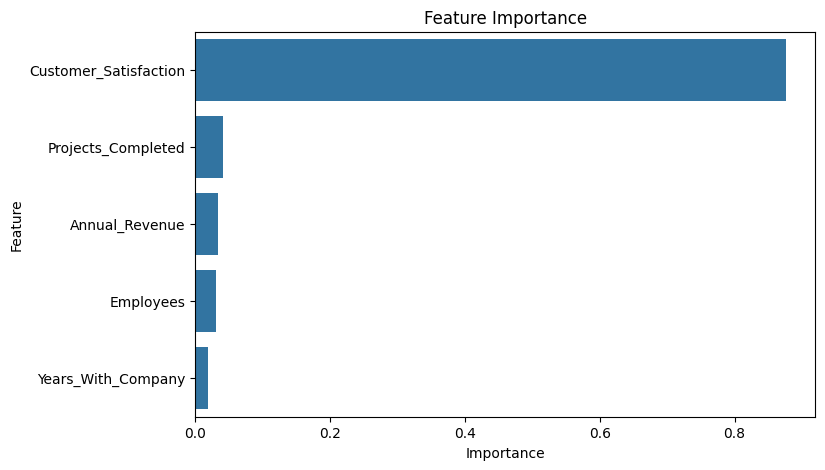

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'

)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Learning Curve Analysis

Learning curves help detect overfitting and underfitting by comparing training and validation performance.
|

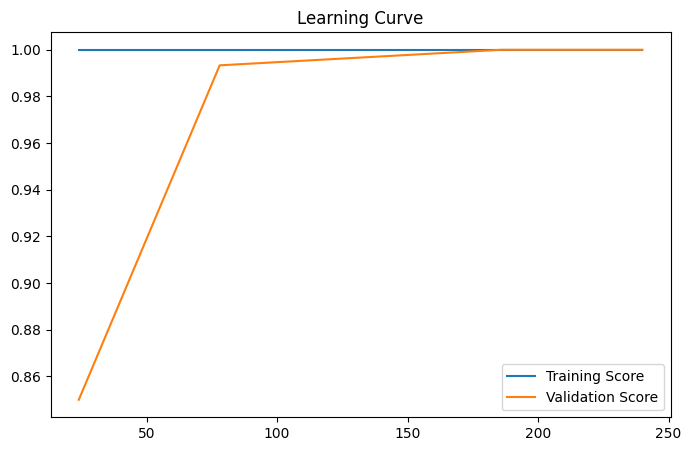

In [19]:
train_sizes, train_scores, test_scores = learning_curve(

    best_model,

    X,

    y,

    cv=5

)

train_mean = train_scores.mean(
    axis=1
)

test_mean = test_scores.mean(
    axis=1
)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    label='Training Score'
)

plt.plot(
    train_sizes,
    test_mean,
    label='Validation Score'
)

plt.legend()

plt.title(
    "Learning Curve"
)

plt.savefig(
    "learning_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Overfitting and Underfitting Analysis

The learning curve provides insight into model generalization. A small gap between training and validation scores indicates balanced learning, while a large gap may suggest overfitting.

In [20]:
# Download Generated Files
from google.colab import files

files.download(
    "optimization_comparison.png"
)

files.download(
    "feature_importance.png"
)

files.download(
    "learning_curve.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Optimization Conclusion

The optimization process confirmed that the Random Forest model was already achieving excellent predictive performance before tuning. GridSearchCV identified the best parameter combination and verified that the model maintained strong generalization capability.

Cross-validation, feature importance analysis, and learning curve evaluation provided additional evidence that the model is reliable, stable, and suitable for project status prediction. Therefore, the primary contribution of optimization in this project was model validation and performance assurance rather than a direct increase in accuracy.



While the model achieved perfect performance on the current dataset, future work could involve larger and more diverse datasets to further evaluate model scalability and generalization under more complex real-world conditions.